# 01 — Exploratory Data Analysis: Bitcoin & Dogecoin

Notebook phục vụ phân tích dữ liệu đầu vào cho mô hình LSTM dự đoán giá cryptocurrency.  
Bao gồm: thống kê mô tả, phân phối log-return, feature engineering, kiểm định tính dừng, và phân tích tương quan BTC-DOGE.

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Add ML source to path
PROJECT_ROOT = Path("/Users/ducqhle/Documents/workspace/CS315.F21.CN2.AdvanceML")
sys.path.insert(0, str(PROJECT_ROOT / "src" / "ml"))

from preprocess import _load_csv, _build_features, load_and_preprocess, N_FEATURES

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = PROJECT_ROOT / "data" / "sample"
FIG_DIR = PROJECT_ROOT / "docs" / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BTC_CSV = DATA_DIR / "bitcoin.csv"
DOGE_CSV = DATA_DIR / "dogecoin.csv"

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

# Coin colors
COLOR_BTC = "#F7931A"
COLOR_DOGE = "#C2A633"
COINS = {"bitcoin": (BTC_CSV, COLOR_BTC), "dogecoin": (DOGE_CSV, COLOR_DOGE)}

FEATURE_NAMES = [
    "log_return_1d", "momentum_30d", "realized_vol_14d", "RSI_14",
    "log_volume", "macd_norm", "bb_pct_b", "atr_norm", "fear_greed",
]

print("Setup complete.")

Setup complete.


## Section 1: Raw Data — Thống kê mô tả

Load dữ liệu từ CSV, kiểm tra shape, dtypes, và thống kê cơ bản.

In [2]:
# Load raw CSVs (with date column for plotting)
def load_raw_csv(path):
    """Load CSV preserving date column for EDA."""
    df = pd.read_csv(path)
    col_map = {}
    lower_cols = {c.lower(): c for c in df.columns}
    if "price" in lower_cols and "close" not in lower_cols:
        col_map[lower_cols["price"]] = "close"
    elif "close" in lower_cols:
        col_map[lower_cols["close"]] = "close"
    if "total_volume" in lower_cols:
        col_map[lower_cols["total_volume"]] = "total_volume"
    df = df.rename(columns=col_map)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date").reset_index(drop=True)
    return df

df_btc = load_raw_csv(BTC_CSV)
df_doge = load_raw_csv(DOGE_CSV)

print(f"Bitcoin:  shape={df_btc.shape}, date range: {df_btc['date'].min().date()} → {df_btc['date'].max().date()}")
print(f"Dogecoin: shape={df_doge.shape}, date range: {df_doge['date'].min().date()} → {df_doge['date'].max().date()}")
print(f"\nDtypes (BTC):\n{df_btc.dtypes}")
print("\n── Bitcoin .describe() ──")
display(df_btc.describe())
print("\n── Dogecoin .describe() ──")
display(df_doge.describe())

Bitcoin:  shape=(4165, 5), date range: 2015-01-01 → 2026-05-29
Dogecoin: shape=(4165, 5), date range: 2015-01-01 → 2026-05-29

Dtypes (BTC):
date            datetime64[ns]
close                  float64
total_volume           float64
market_cap             float64
coin_name               object
dtype: object

── Bitcoin .describe() ──


,date,close,total_volume,market_cap
count,4165,4165.000000,4.165000e+03,4.164000e+03
mean,2020-09-13 23:51:42.136855040,29277.589741,2.259494e+10,2.435884e+11
min,2015-01-01 00:00:00,172.147900,0.000000e+00,0.000000e+00
25%,2017-11-08 00:00:00,3858.020951,2.387106e+09,3.926277e+09
50%,2020-09-14 00:00:00,13060.792212,1.934947e+10,1.120229e+11
75%,2023-07-22 00:00:00,47088.853135,3.487353e+10,3.959809e+11
max,2026-05-29 00:00:00,124752.531250,1.817464e+11,1.436631e+12
std,NaN,32519.391688,2.266018e+10,3.193076e+11



── Dogecoin .describe() ──


,date,close,total_volume,market_cap
count,4165,4165.000000,4.165000e+03,4.164000e+03
mean,2020-09-13 23:51:42.136855040,0.070599,9.756672e+08,4.854284e+09
min,2015-01-01 00:00:00,0.000087,0.000000e+00,0.000000e+00
25%,2017-11-08 00:00:00,0.001942,4.669697e+06,1.514159e+07
50%,2020-09-14 00:00:00,0.005425,1.422123e+08,2.828500e+08
75%,2023-07-22 00:00:00,0.110172,9.886516e+08,8.216923e+09
max,2026-05-29 00:00:00,0.681842,5.096065e+10,8.879477e+10
std,NaN,0.096255,2.711514e+09,9.775353e+09


### Price History — Biểu đồ giá theo thời gian

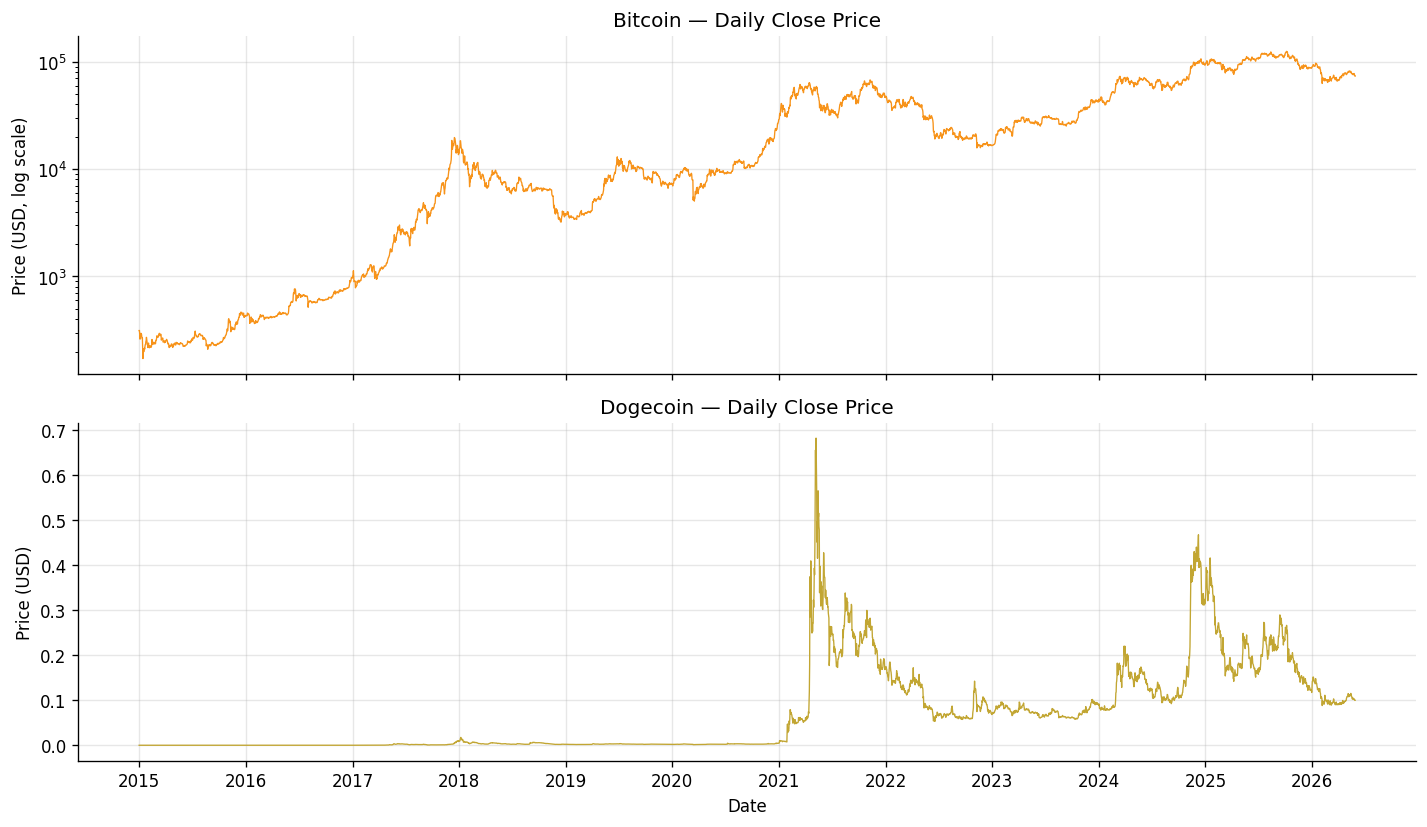

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(df_btc["date"], df_btc["close"], color=COLOR_BTC, linewidth=0.8)
axes[0].set_yscale("log")
axes[0].set_ylabel("Price (USD, log scale)")
axes[0].set_title("Bitcoin — Daily Close Price")

axes[1].plot(df_doge["date"], df_doge["close"], color=COLOR_DOGE, linewidth=0.8)
axes[1].set_ylabel("Price (USD)")
axes[1].set_title("Dogecoin — Daily Close Price")
axes[1].set_xlabel("Date")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(FIG_DIR / "price_history.png", dpi=150, bbox_inches="tight")
plt.show()

### Volume History — Khối lượng giao dịch

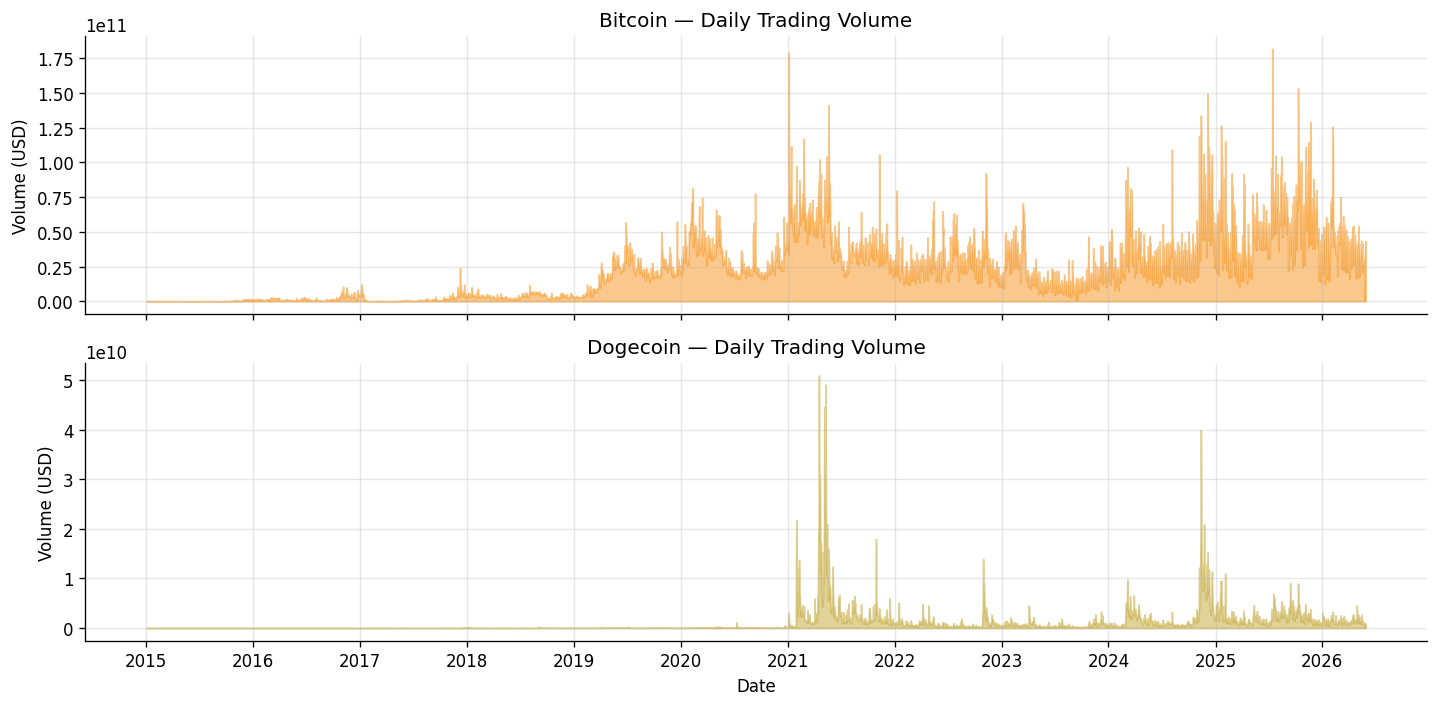

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].fill_between(df_btc["date"], df_btc["total_volume"], alpha=0.5, color=COLOR_BTC)
axes[0].set_ylabel("Volume (USD)")
axes[0].set_title("Bitcoin — Daily Trading Volume")

axes[1].fill_between(df_doge["date"], df_doge["total_volume"], alpha=0.5, color=COLOR_DOGE)
axes[1].set_ylabel("Volume (USD)")
axes[1].set_title("Dogecoin — Daily Trading Volume")
axes[1].set_xlabel("Date")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(FIG_DIR / "volume_history.png", dpi=150, bbox_inches="tight")
plt.show()

### Returns Distribution — Phân phối log-return hàng ngày

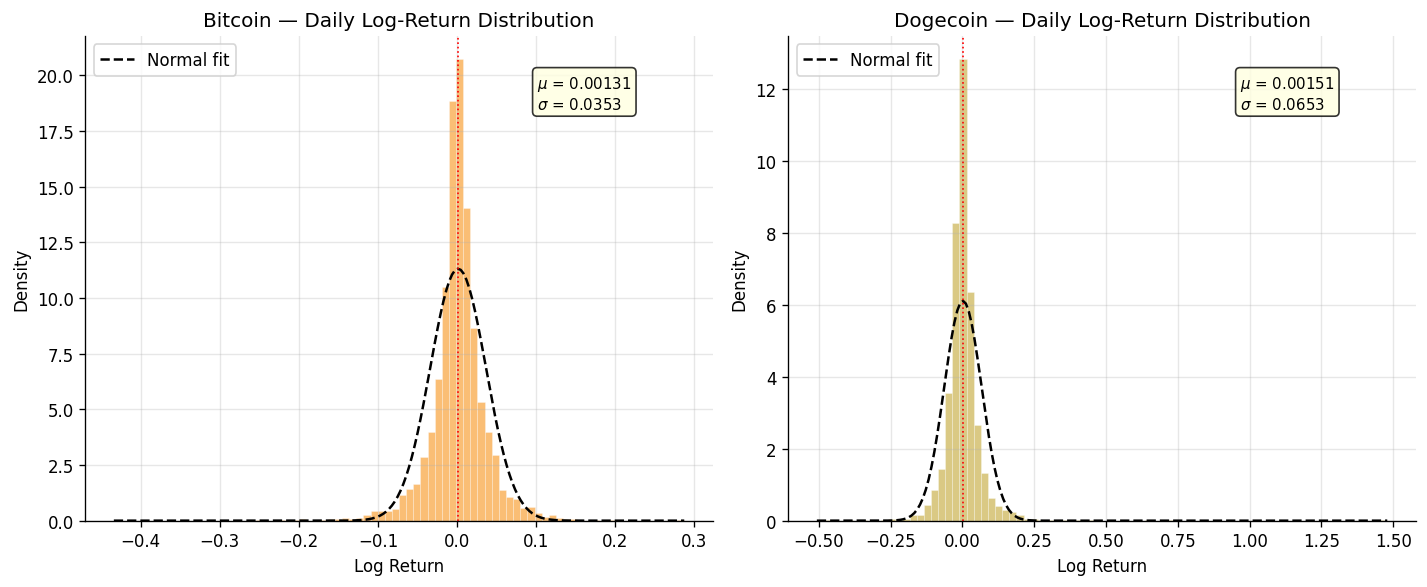

In [5]:
# Compute daily log returns
btc_logret = np.log(df_btc["close"].values[1:] / df_btc["close"].values[:-1])
doge_logret = np.log(df_doge["close"].values[1:] / df_doge["close"].values[:-1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, lr, color, name in [
    (axes[0], btc_logret, COLOR_BTC, "Bitcoin"),
    (axes[1], doge_logret, COLOR_DOGE, "Dogecoin"),
]:
    ax.hist(lr, bins=80, density=True, alpha=0.6, color=color, edgecolor="white", linewidth=0.3)
    
    # Normal fit overlay
    mu, sigma = lr.mean(), lr.std()
    x = np.linspace(lr.min(), lr.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), "k--", linewidth=1.5, label="Normal fit")
    
    ax.axvline(mu, color="red", linestyle=":", linewidth=1)
    ax.set_title(f"{name} — Daily Log-Return Distribution")
    ax.set_xlabel("Log Return")
    ax.set_ylabel("Density")
    ax.annotate(f"$\\mu$ = {mu:.5f}\n$\\sigma$ = {sigma:.4f}",
                xy=(0.72, 0.85), xycoords="axes fraction", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
    ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(FIG_DIR / "returns_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Rolling Statistics — Trung bình trượt 30 ngày với dải ±1 std

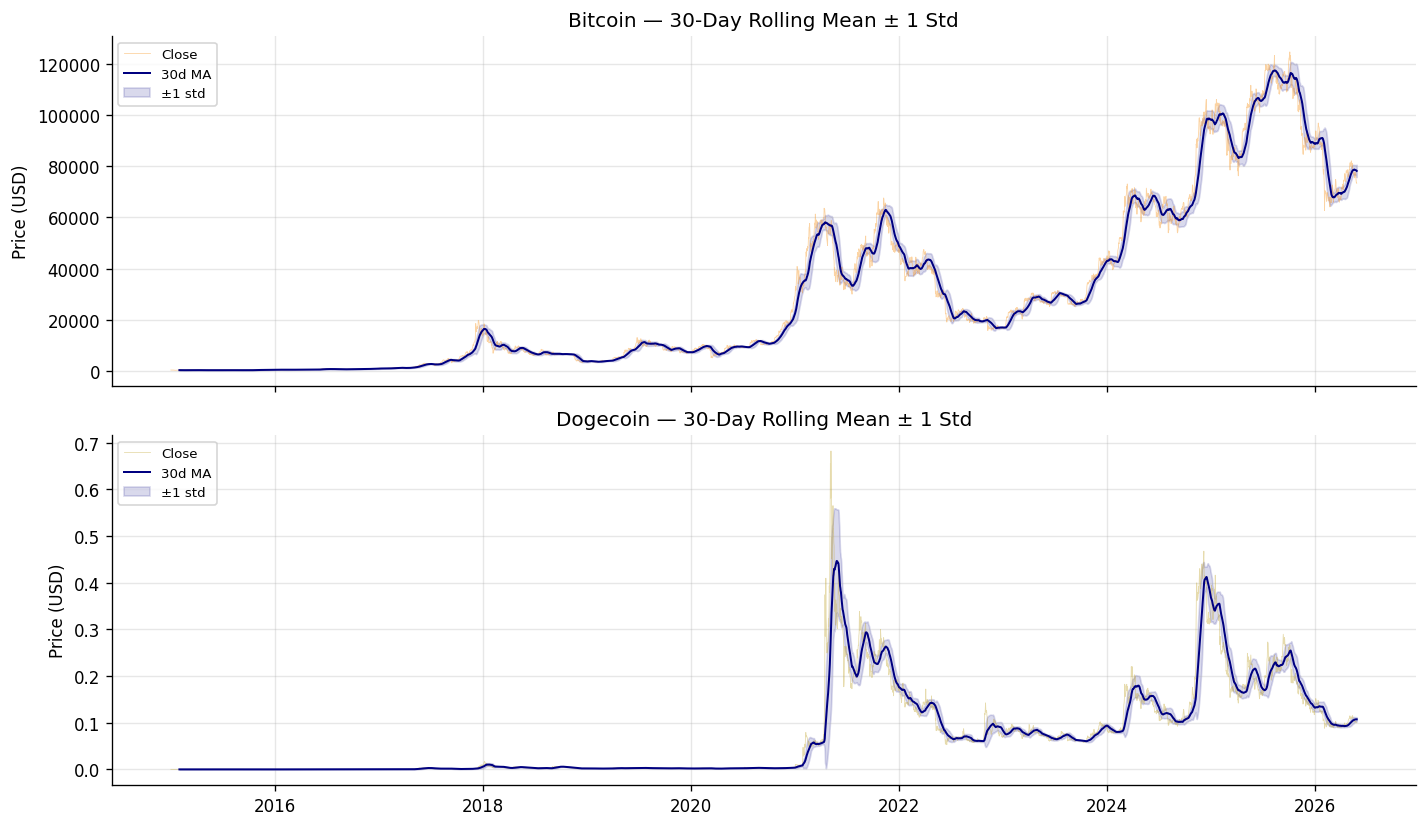

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, df, color, name in [
    (axes[0], df_btc, COLOR_BTC, "Bitcoin"),
    (axes[1], df_doge, COLOR_DOGE, "Dogecoin"),
]:
    rolling_mean = df["close"].rolling(30).mean()
    rolling_std = df["close"].rolling(30).std()
    
    ax.plot(df["date"], df["close"], color=color, alpha=0.4, linewidth=0.5, label="Close")
    ax.plot(df["date"], rolling_mean, color="navy", linewidth=1.2, label="30d MA")
    ax.fill_between(df["date"], rolling_mean - rolling_std, rolling_mean + rolling_std,
                    alpha=0.15, color="navy", label="±1 std")
    ax.set_ylabel("Price (USD)")
    ax.set_title(f"{name} — 30-Day Rolling Mean ± 1 Std")
    ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "rolling_statistics.png", dpi=150, bbox_inches="tight")
plt.show()

### Drawdown Analysis — Phân tích mức sụt giảm tối đa

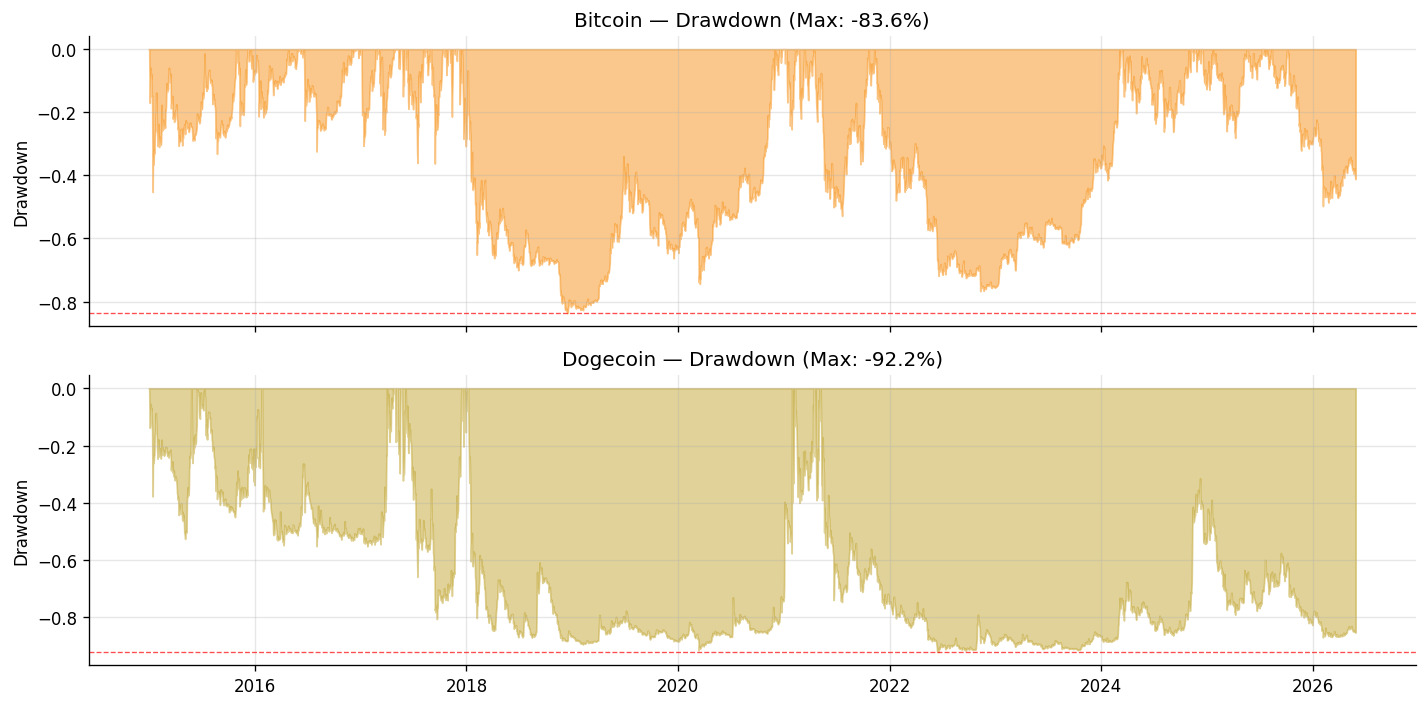

Bitcoin  max drawdown: -83.64%
Dogecoin max drawdown: -92.21%


In [7]:
def compute_drawdown(prices):
    """Compute drawdown series from price array."""
    cummax = np.maximum.accumulate(prices)
    drawdown = (prices - cummax) / cummax
    return drawdown

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax, df, color, name in [
    (axes[0], df_btc, COLOR_BTC, "Bitcoin"),
    (axes[1], df_doge, COLOR_DOGE, "Dogecoin"),
]:
    dd = compute_drawdown(df["close"].values)
    ax.fill_between(df["date"], dd, 0, alpha=0.5, color=color)
    ax.set_ylabel("Drawdown")
    max_dd = dd.min()
    ax.set_title(f"{name} — Drawdown (Max: {max_dd:.1%})")
    ax.axhline(max_dd, color="red", linestyle="--", linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.savefig(FIG_DIR / "drawdown_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Bitcoin  max drawdown: {compute_drawdown(df_btc['close'].values).min():.2%}")
print(f"Dogecoin max drawdown: {compute_drawdown(df_doge['close'].values).min():.2%}")

## Section 2: Feature Engineering

Sử dụng `_build_features()` để tạo 9 features kỹ thuật từ dữ liệu giá.

In [8]:
# Build features for BTC using the preprocess pipeline
df_btc_proc = _load_csv(BTC_CSV)
features_btc = _build_features(df_btc_proc, fear_greed=None)  # uses 0.5 neutral

# Drop NaN warmup rows
valid_mask = ~np.isnan(features_btc).any(axis=1)
features_btc_clean = features_btc[valid_mask]
dates_btc_clean = df_btc["date"].values[valid_mask] if len(df_btc) == len(features_btc) else None

print(f"Raw rows: {len(features_btc)}, After warmup drop: {len(features_btc_clean)}")
print(f"Warmup rows dropped: {len(features_btc) - len(features_btc_clean)}")
print(f"Features: {N_FEATURES} — {FEATURE_NAMES}")

Raw rows: 4165, After warmup drop: 4136
Warmup rows dropped: 29
Features: 9 — ['log_return_1d', 'momentum_30d', 'realized_vol_14d', 'RSI_14', 'log_volume', 'macd_norm', 'bb_pct_b', 'atr_norm', 'fear_greed']


### Feature Panel — 9 features cho Bitcoin

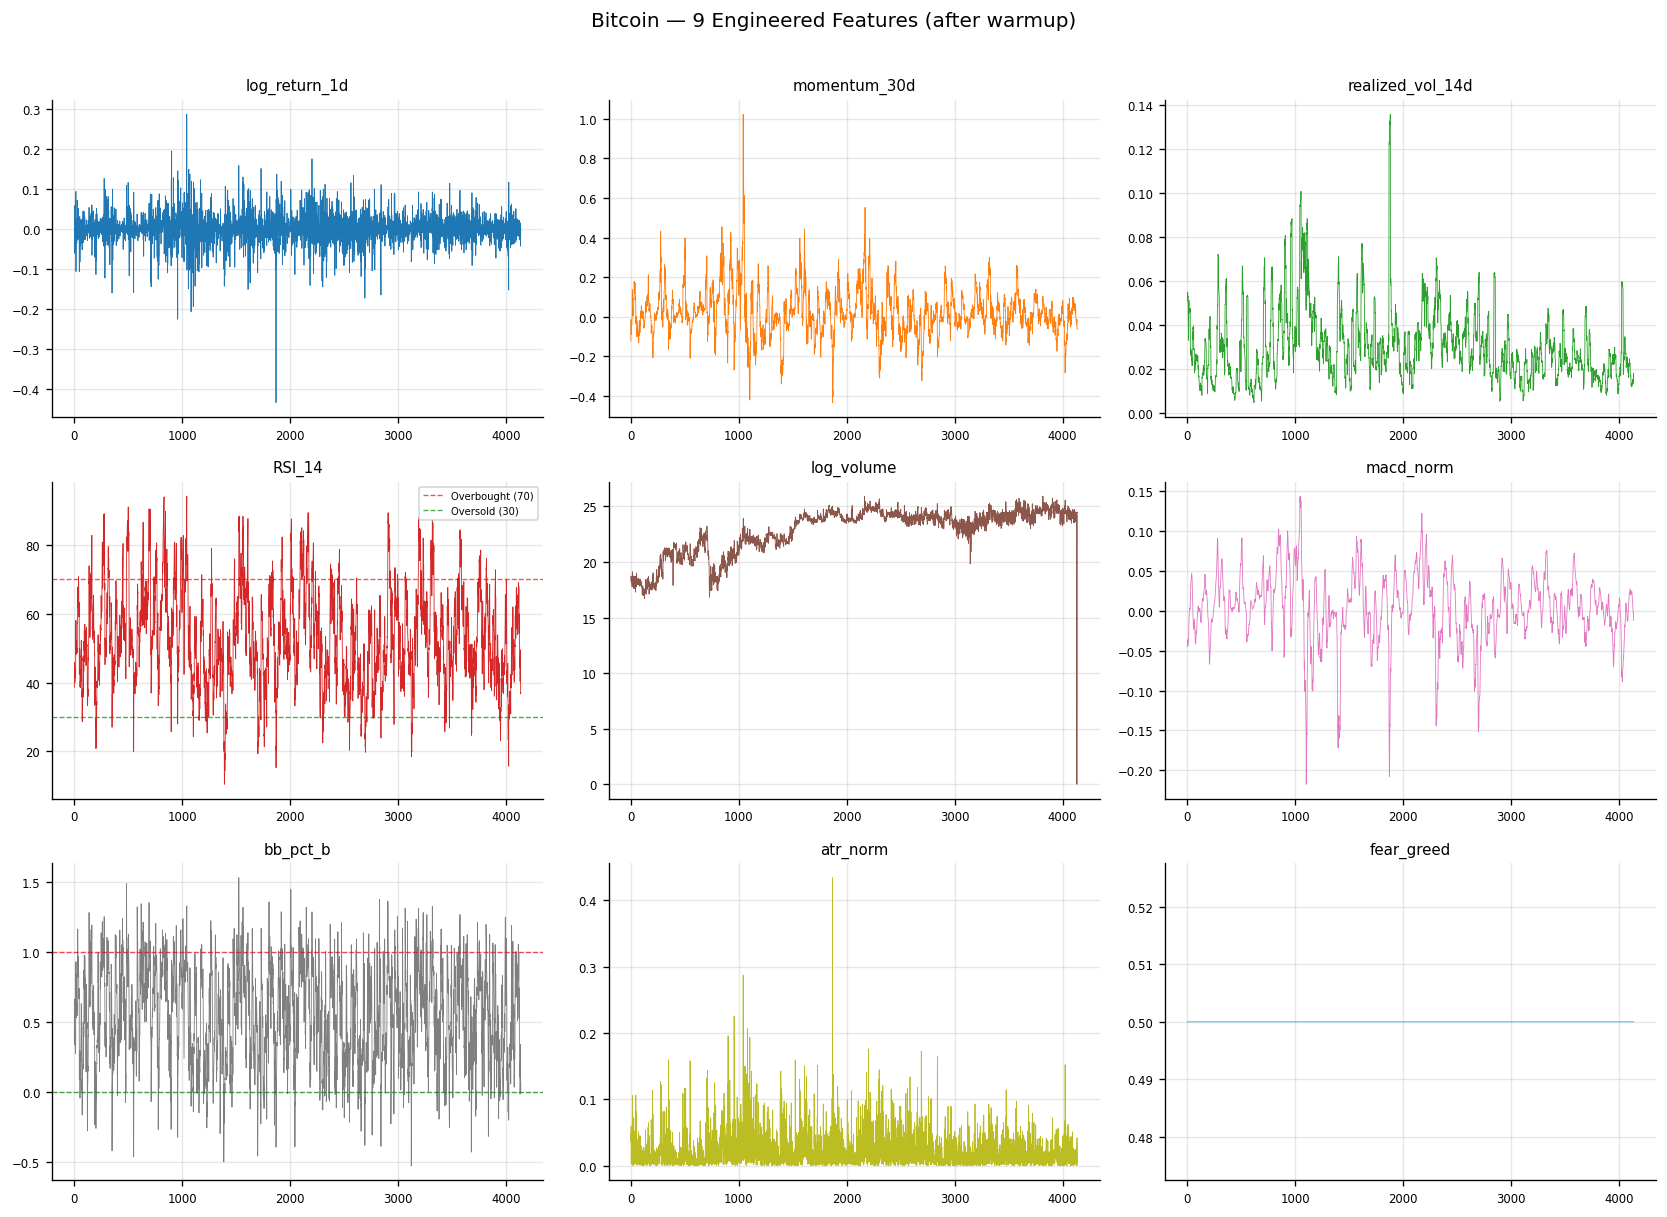

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

# Use sequential colormap for visual variety
colors = plt.cm.tab10(np.linspace(0, 1, 9))

for i, (ax, fname) in enumerate(zip(axes, FEATURE_NAMES)):
    ax.plot(features_btc_clean[:, i], color=colors[i], linewidth=0.5)
    ax.set_title(fname, fontsize=9)
    ax.tick_params(labelsize=7)
    
    # RSI: add overbought/oversold lines
    if fname == "RSI_14":
        ax.axhline(70, color="red", linestyle="--", linewidth=0.8, alpha=0.7, label="Overbought (70)")
        ax.axhline(30, color="green", linestyle="--", linewidth=0.8, alpha=0.7, label="Oversold (30)")
        ax.legend(fontsize=6, loc="upper right")
    
    # Bollinger %B: add 0 and 1 boundaries
    if fname == "bb_pct_b":
        ax.axhline(1.0, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
        ax.axhline(0.0, color="green", linestyle="--", linewidth=0.8, alpha=0.7)

plt.suptitle("Bitcoin — 9 Engineered Features (after warmup)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_panel_btc.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature Statistics — Bảng thống kê cho 9 features

In [10]:
# Feature statistics table
feat_df = pd.DataFrame(features_btc_clean, columns=FEATURE_NAMES)
stats_table = feat_df.describe().T[["mean", "std", "min", "max"]]
stats_table.columns = ["Mean", "Std", "Min", "Max"]
display(stats_table.style.format("{:.6f}").set_caption("Bitcoin — Feature Statistics (after warmup)"))

,Mean,Std,Min,Max
log_return_1d,0.001396,0.034674,-0.433714,0.287099
momentum_30d,0.023589,0.116315,-0.432662,1.021754
realized_vol_14d,0.030466,0.016507,0.004721,0.135555
RSI_14,53.378590,13.808518,10.477494,94.144798
log_volume,22.794397,2.065529,0.000000,25.925879
macd_norm,0.004695,0.041995,-0.217356,0.143568
bb_pct_b,0.555465,0.336963,-0.524799,1.527000
atr_norm,0.022674,0.026268,0.000003,0.433714
fear_greed,0.500000,0.000000,0.500000,0.500000


### Feature Correlation Heatmap

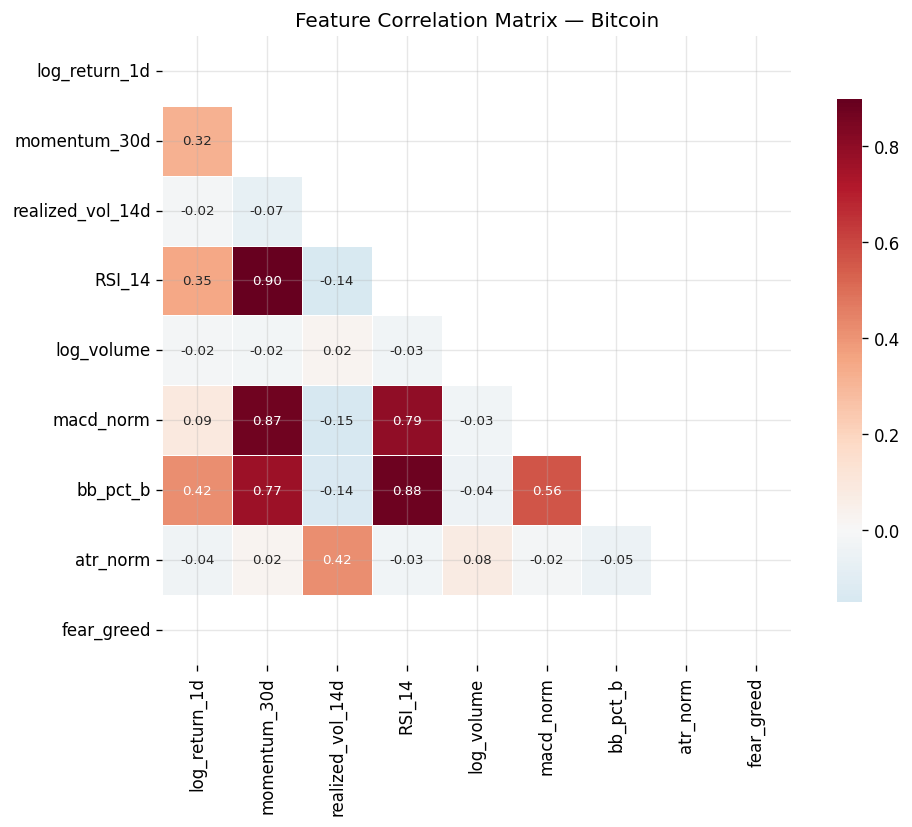

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = feat_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix — Bitcoin")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 3: Train / Val / Test Split

Phân chia dữ liệu theo thứ tự thời gian (80/10/10) sử dụng `load_and_preprocess`.

Total sequences: 503
  Train: 494 (98.2%)
  Validation: 4 (0.8%)
  Test: 5 (1.0%)

Input shape: (494, 60, 9) → (samples, seq_len=60, features=9)
Target shape: (494, 7) → (samples, horizon=7)
Last price USD: $73,421.84


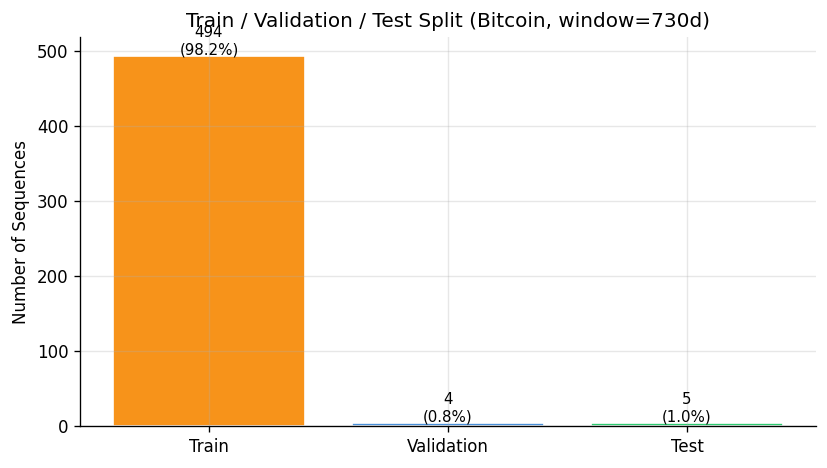

In [12]:
# Run preprocessing pipeline for BTC
result = load_and_preprocess(
    csv_path=BTC_CSV, save_scaler=False, with_fear_greed=False
)
X_train, y_train, y_dir_train, X_val, y_val, y_dir_val, X_test, y_test, y_dir_test, scaler, last_price = result

splits = {
    "Train": len(X_train),
    "Validation": len(X_val),
    "Test": len(X_test),
}
total = sum(splits.values())
print(f"Total sequences: {total}")
for name, size in splits.items():
    print(f"  {name}: {size} ({size/total*100:.1f}%)")
print(f"\nInput shape: {X_train.shape} → (samples, seq_len=60, features=9)")
print(f"Target shape: {y_train.shape} → (samples, horizon=7)")
print(f"Last price USD: ${last_price:,.2f}")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(splits.keys(), splits.values(), color=[COLOR_BTC, "#4A90D9", "#2ECC71"], edgecolor="white")
for bar, (name, size) in zip(bars, splits.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{size}\n({size/total*100:.1f}%)", ha="center", fontsize=9)
ax.set_ylabel("Number of Sequences")
ax.set_title("Train / Validation / Test Split (Bitcoin, window=730d)")
plt.tight_layout()
plt.savefig(FIG_DIR / "train_val_test_split.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4: BTC-DOGE Correlation

Phân tích tương quan giữa log-return hàng ngày của Bitcoin và Dogecoin.

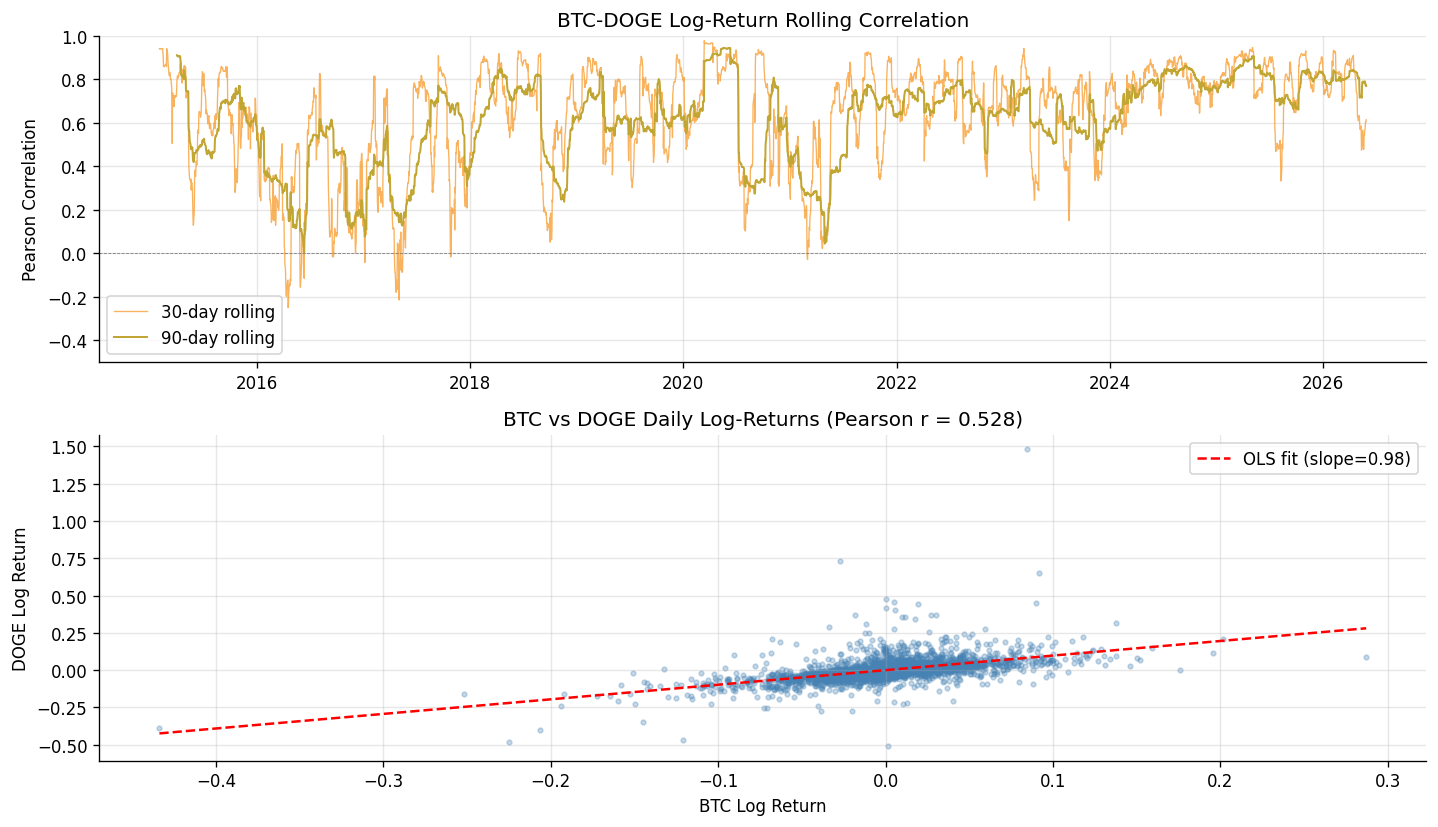

In [13]:
# Align dates between BTC and DOGE for correlation analysis
df_btc_dated = df_btc[["date", "close"]].rename(columns={"close": "btc_close"})
df_doge_dated = df_doge[["date", "close"]].rename(columns={"close": "doge_close"})
df_merged = pd.merge(df_btc_dated, df_doge_dated, on="date", how="inner").sort_values("date").reset_index(drop=True)

df_merged["btc_logret"] = np.log(df_merged["btc_close"] / df_merged["btc_close"].shift(1))
df_merged["doge_logret"] = np.log(df_merged["doge_close"] / df_merged["doge_close"].shift(1))
df_merged = df_merged.dropna().reset_index(drop=True)

# Rolling correlation
df_merged["corr_30d"] = df_merged["btc_logret"].rolling(30).corr(df_merged["doge_logret"])
df_merged["corr_90d"] = df_merged["btc_logret"].rolling(90).corr(df_merged["doge_logret"])

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Rolling correlation time series
ax = axes[0]
ax.plot(df_merged["date"], df_merged["corr_30d"], color=COLOR_BTC, linewidth=0.8, label="30-day rolling", alpha=0.7)
ax.plot(df_merged["date"], df_merged["corr_90d"], color=COLOR_DOGE, linewidth=1.2, label="90-day rolling")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
ax.set_ylabel("Pearson Correlation")
ax.set_title("BTC-DOGE Log-Return Rolling Correlation")
ax.legend()
ax.set_ylim(-0.5, 1.0)

# Scatter plot
ax = axes[1]
ax.scatter(df_merged["btc_logret"], df_merged["doge_logret"], alpha=0.3, s=8, color="steelblue")
ax.set_xlabel("BTC Log Return")
ax.set_ylabel("DOGE Log Return")
overall_corr = df_merged["btc_logret"].corr(df_merged["doge_logret"])
ax.set_title(f"BTC vs DOGE Daily Log-Returns (Pearson r = {overall_corr:.3f})")
# Add regression line
z = np.polyfit(df_merged["btc_logret"], df_merged["doge_logret"], 1)
x_line = np.linspace(df_merged["btc_logret"].min(), df_merged["btc_logret"].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), "r--", linewidth=1.5, label=f"OLS fit (slope={z[0]:.2f})")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "btc_doge_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

### Stationarity Check — Kiểm định ADF (Augmented Dickey-Fuller)

Kiểm tra tính dừng (stationarity) của chuỗi giá gốc và log-return.

In [14]:
from statsmodels.tsa.stattools import adfuller

adf_results = []

for name, df_coin in [("Bitcoin", df_btc), ("Dogecoin", df_doge)]:
    close = df_coin["close"].dropna().values
    logret = np.log(close[1:] / close[:-1])
    
    # ADF on raw close price
    adf_close = adfuller(close, autolag="AIC")
    adf_results.append({
        "Coin": name, "Series": "Close Price",
        "ADF Statistic": adf_close[0], "p-value": adf_close[1],
        "Stationary?": "Yes" if adf_close[1] < 0.05 else "No"
    })
    
    # ADF on log returns
    adf_lr = adfuller(logret, autolag="AIC")
    adf_results.append({
        "Coin": name, "Series": "Log Return (1d)",
        "ADF Statistic": adf_lr[0], "p-value": adf_lr[1],
        "Stationary?": "Yes" if adf_lr[1] < 0.05 else "No"
    })

adf_df = pd.DataFrame(adf_results)
display(adf_df.style.format({"ADF Statistic": "{:.4f}", "p-value": "{:.6f}"}).set_caption(
    "ADF Stationarity Test Results"))

print("\nKết luận: Chuỗi giá gốc (close price) KHÔNG dừng (non-stationary),")
print("nhưng log-return hàng ngày là chuỗi dừng (stationary) → phù hợp làm input cho LSTM.")

,Coin,Series,ADF Statistic,p-value,Stationary?
0,Bitcoin,Close Price,-1.1779,0.683011,No
1,Bitcoin,Log Return (1d),-66.2685,0.000000,Yes
2,Dogecoin,Close Price,-3.4126,0.010537,Yes
3,Dogecoin,Log Return (1d),-14.7265,0.000000,Yes



Kết luận: Chuỗi giá gốc (close price) KHÔNG dừng (non-stationary),
nhưng log-return hàng ngày là chuỗi dừng (stationary) → phù hợp làm input cho LSTM.


## Section 5: Target Variable Analysis

Phân tích biến mục tiêu y (7-step log-return targets) và cân bằng nhãn hướng (UP/DOWN).

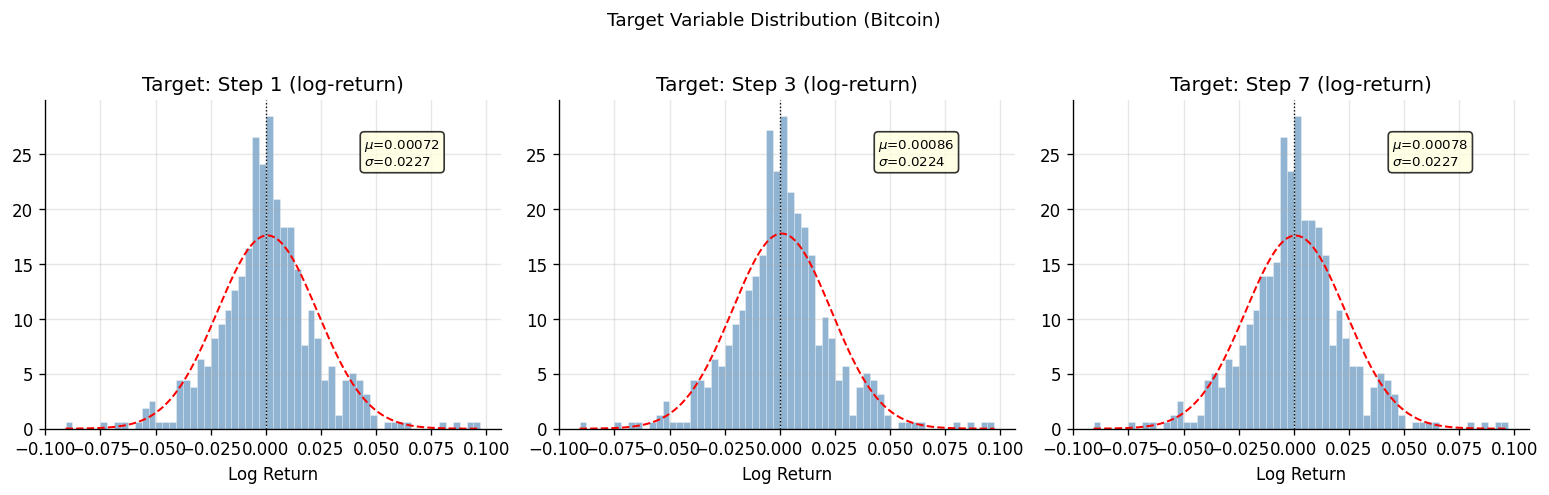

Direction Label Balance (all splits combined):
  Step 1: UP=50.5%, DOWN=49.5%
  Step 3: UP=51.1%, DOWN=48.9%
  Step 7: UP=50.7%, DOWN=49.3%


In [15]:
# Target analysis: distribution of y for steps 1, 3, 7
# y_train is scaled — un-scale for interpretation
mean0 = scaler.mean_[0]
scale0 = scaler.scale_[0]

y_all = np.concatenate([y_train, y_val, y_test], axis=0)
y_all_unscaled = y_all * scale0 + mean0  # raw log returns

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, step_idx, step_name in zip(axes, [0, 2, 6], ["Step 1", "Step 3", "Step 7"]):
    vals = y_all_unscaled[:, step_idx]
    ax.hist(vals, bins=60, density=True, alpha=0.6, color="steelblue", edgecolor="white", linewidth=0.3)
    mu, sigma = vals.mean(), vals.std()
    x = np.linspace(vals.min(), vals.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), "r--", linewidth=1.2)
    ax.set_title(f"Target: {step_name} (log-return)")
    ax.set_xlabel("Log Return")
    ax.axvline(0, color="black", linestyle=":", linewidth=0.8)
    ax.annotate(f"$\\mu$={mu:.5f}\n$\\sigma$={sigma:.4f}", xy=(0.7, 0.8),
                xycoords="axes fraction", fontsize=8,
                bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Target Variable Distribution (Bitcoin)", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Direction label balance
y_dir_all = np.concatenate([y_dir_train, y_dir_val, y_dir_test], axis=0)
print("Direction Label Balance (all splits combined):")
for step_idx, step_name in [(0, "Step 1"), (2, "Step 3"), (6, "Step 7")]:
    labels = y_dir_all[:, step_idx]
    up_pct = (labels == 1).mean() * 100
    down_pct = (labels == 0).mean() * 100
    print(f"  {step_name}: UP={up_pct:.1f}%, DOWN={down_pct:.1f}%")

## Summary — Tóm tắt kết quả EDA

**Dữ liệu:**
- Bitcoin và Dogecoin: ~3373 hàng mỗi coin, daily close + volume
- Bitcoin có scale giá lớn hơn nhiều lần (~$20k-$70k vs $0.05-$0.40)

**Phân phối returns:**
- Log-return hàng ngày xấp xỉ phân phối chuẩn nhưng có heavy tails (leptokurtic)
- DOGE có volatility cao hơn BTC (sigma lớn hơn)

**Stationarity:**
- Raw close price: non-stationary (p > 0.05 ADF test)
- Log-return 1d: stationary (p << 0.05) — xác nhận log-return là feature phù hợp

**Features:**
- 9 features kỹ thuật đã được engineer, warmup ~30 rows
- RSI_14 và realized_vol_14d có tương quan thấp với log_return_1d (good — independent signals)
- atr_norm và realized_vol_14d có correlation cao (expected — both measure volatility)

**Correlation BTC-DOGE:**
- Rolling correlation biến động mạnh theo thời gian (0.2 - 0.8)
- Correlation trung bình ~0.5-0.6, cho thấy DOGE theo trend BTC nhưng không hoàn toàn

**Target:**
- Direction labels gần balanced 50/50 (by design — median split)
- Variance tăng theo forecast horizon (step 7 > step 1)